# Projeto
O projeto Agroscope (IA) visa introduzir visão computacional para identificar padrões estruturais e texturas em folhas de plantas, de modo a identificar possíveis pragas.

## Importando Classes

In [1]:
# Torch
import torch
import torch.nn as nn
from torchvision import models
import torchvision.datasets as datasets
from torch.utils.data import random_split, Subset

# Numpy
import numpy as np

import random
import os

# Módulos Próprios
from utils.models import Get_Transform, TransformType

from dotenv import load_dotenv

In [2]:
torch.manual_seed(42)
np.random.seed(42)
print(".env loaded sucessfully" if load_dotenv() else "couldn't load .env")

.env loaded sucessfully


# Definições

In [3]:
NET = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

In [4]:
# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EPOCH = 3

# Variáveis de Ambiente
BATCH_SIZE = 32

# Learning Rates
LR_LAYER4 = 1e-4
LR_FC = 1e-3

DATA_PATH = os.getenv("DATA_PATH")

print(f"Dispositivo Usado: {"GPU" if DEVICE.type == "cuda" else "CPU"}")

Dispositivo Usado: GPU


## Transform

In [5]:
transform_train = Get_Transform(TransformType.TRAIN)
transform_eval = Get_Transform(TransformType.EVAL)

## Dataset Principal

In [6]:
dataset = datasets.ImageFolder(root=DATA_PATH, transform=transform_train)
num_labels = len(dataset.classes)

In [7]:
# Pode ser simplificado
class Balance:
    def __init__(self):
        pass

    def __call__(self, value :int=None):
        class_indices = {}
        for label in range(num_labels):
            class_indices[label] = []

        for idx, (_, label) in enumerate(dataset.imgs):
            class_indices[label].append(idx)


        low = value
        for _, imgs in class_indices.items():
            if low == None:
                low = len(imgs)
            else:
                if low >= len(imgs):
                    low = len(imgs)
                else:
                    continue

        return class_indices, low
    
    
class_indices, low = Balance().__call__(1200)

In [8]:
balanced_indices = []

for class_label, indices in class_indices.items():
    if len(indices) > low:
        random.shuffle(indices)
        selected_indices = indices[:low]
    else:
        selected_indices = indices

    balanced_indices.extend(selected_indices)
    print(f"Class {class_label}: {len(selected_indices)}")

random.shuffle(balanced_indices)
balanced_dataset = Subset(dataset, balanced_indices)

Class 0: 676
Class 1: 676
Class 2: 676


In [9]:
dataset_len = len(balanced_dataset)

train_size = int(0.7 * dataset_len)
val_size = int(0.15 * dataset_len)
test_size = dataset_len - train_size - val_size

print(f"All Dataset: {dataset_len}")
print(f"Train (70%): {train_size}")
print(f"Eval (15%): {val_size}")
print(f"Test (15%): {test_size}")

All Dataset: 2028
Train (70%): 1419
Eval (15%): 304
Test (15%): 305


In [10]:
train_dataset, val_dataset, test_dataset = random_split(
    balanced_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
    )

val_dataset.dataset.transform = transform_eval
test_dataset.dataset.transform = transform_eval

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, num_workers=4, shuffle=True)

In [11]:
print("Classes:", balanced_dataset.dataset.classes)
print(f"Split -> train={len(train_dataset)} val={len(val_dataset)} test={len(test_dataset)}")

Classes: ['Bacterial_Spot', 'Healthy', 'Leaf_Mold']
Split -> train=1419 val=304 test=305


# Modelo
Usaremos um modelo já treinado com entendimento de padrões para podermos realizar um transfer-learning e aprimora-lo com dados próprios.

In [12]:
in_features = NET.classifier[2].in_features
NET.classifier[2] = nn.Linear(in_features, num_labels)

In [13]:
# Descongelando apenas as últimas camadas
for param in NET.parameters():
    param.requires_grad = False

# Palavras chaves para ativação de gradiente
keywords = ["fc", "classifier", "heads", "layer4", "denseblock4", "features.7", "features.8", "encoder.layers.11"]

for name, param in NET.named_parameters():
    if any(k in name for k in keywords):
        param.requires_grad = True

In [14]:
weight_decay=1e-4

backbone_params = [p for n, p in NET.named_parameters() if p.requires_grad and "classifier" not in n]
head_params = [p for n, p in NET.named_parameters() if p.requires_grad and "classifier" in n]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": LR_LAYER4},
    {"params": head_params, "lr": LR_FC},
], weight_decay=weight_decay)

criterion = nn.CrossEntropyLoss()

# Scheduler - Necessário para ajuste automático do learning rate
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCH)

# Treinando o modelo

In [15]:
NET.to(DEVICE)

# Historico para diagnostico de overfitting (train vs val por epoca)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(EPOCH):

    running_loss = .0
    running_correct = 0
    NET.train()

    print(f"Iteration: {epoch + 1}")

    for batch_idx, (images, labels) in enumerate(train_loader):
        inputs = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = NET(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * inputs.size(0)
        running_correct += (outputs.argmax(dim=1) == labels).sum().item()

    train_loss = running_loss / len(train_dataset)
    train_acc = running_correct / len(train_dataset)

    corrects = []
    NET.eval()
    classified_right = 0
    running_val_loss = .0

    print("Evaluationg on validation set")
    for i, (images, labels) in enumerate(val_loader):
        with torch.no_grad():
            inputs = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = NET(inputs)
            _, pred_classes = torch.max(outputs, 1)

            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            classified_right += (pred_classes == labels).sum().item()

    val_accuracy = classified_right / len(val_dataset)
    val_loss = running_val_loss / len(val_dataset)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_accuracy)

    print(f"Epoch {epoch + 1} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | val_acc: {val_accuracy:.4f}")


Iteration: 1
Evaluationg on validation set
Epoch 1 | train_loss: 0.5084 | val_loss: 0.0873 | train_acc: 0.8471 | val_acc: 0.9901
Iteration: 2
Evaluationg on validation set
Epoch 2 | train_loss: 0.0726 | val_loss: 0.0391 | train_acc: 0.9915 | val_acc: 0.9901
Iteration: 3
Evaluationg on validation set
Epoch 3 | train_loss: 0.0290 | val_loss: 0.0232 | train_acc: 0.9965 | val_acc: 0.9934


## Diagnóstico de Overfitting (curvas de treino vs. validação)
Como ler o gráfico abaixo:
- **Loss de treino caindo e loss de validação subindo (ou estagnada)** = overfitting claro. A partir da época em que a linha de validação vira pra cima, o modelo está decorando o treino.
- **As duas caindo juntas, com um gap pequeno e estável** = sem overfitting relevante; se a acurácia ainda está baixa, é sinal de underfitting (falta capacidade/dado), não excesso.
- **Gap grande entre acurácia de treino e validação** (ex. treino 98%, val 80%) mesmo com as losses ainda caindo = overfitting já instalado, mesmo que a loss de validação não tenha subido ainda — geralmente o próximo sinal.


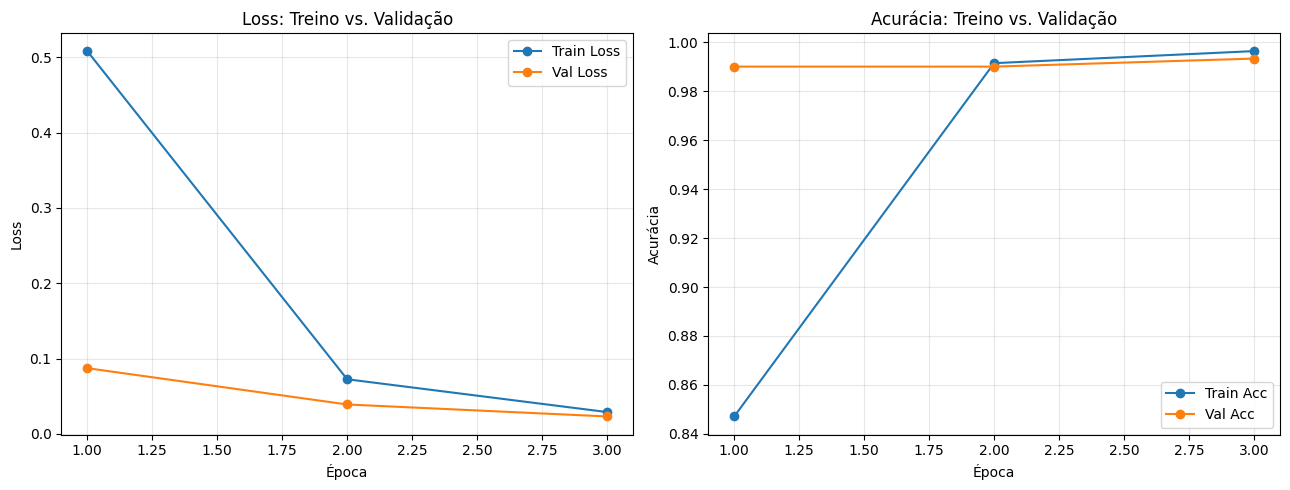

Gap final (train_acc - val_acc): 0.0031


In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss: Treino vs. Validação")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_range, history["val_acc"], label="Val Acc", marker="o")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Acurácia")
axes[1].set_title("Acurácia: Treino vs. Validação")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap = history["train_acc"][-1] - history["val_acc"][-1]
print(f"Gap final (train_acc - val_acc): {gap:.4f}")

# Avaliando o modelo
Métricas de avaliação avançadas devem ser aplicadas para validar o resultado, como visto na etapa 1.

In [17]:
# Avaliação de resultados
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score

In [18]:
NET.to(DEVICE)
NET.eval()
total_loss, y_true, y_pred = 0.0, [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = NET(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

avg_loss = total_loss / len(test_loader.dataset)
acc = (np.array(y_true) == np.array(y_pred)).mean()
f1m = f1_score(y_true, y_pred, average="macro")
bacc = balanced_accuracy_score(y_true, y_pred)
    
print(f"""
avg_loss: {avg_loss}
acc: {acc}
f1m: {f1m}
bacc: {bacc}
""")


avg_loss: 0.0301249375902727
acc: 0.9934426229508196
f1m: 0.9925491175491176
bacc: 0.9927536231884058



# Teste Manual
__logits__: Valores brutos (ou pontuações) gerados pela última camada linear de uma rede neural antes de passarem por uma função de ativação, como softmax ou sigmóide

In [19]:
EVAL_PATH = os.getenv("EVAL_PATH")
NET.to(DEVICE)
NET.eval()

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [20]:
dataset_eval = datasets.ImageFolder(root="/media/kaua-matheus/HD3201/Data/Agroscope/Tomato/Test_Tomato", transform=transform_eval)
dataset_eval.class_to_idx = dataset.class_to_idx
dataset_eval.samples = [(path, dataset.class_to_idx[dataset_eval.classes[old_idx]])
                         for path, old_idx in dataset_eval.samples]
dataset_eval.targets = [s[1] for s in dataset_eval.samples]

eval_loader = torch.utils.data.DataLoader(dataset_eval, batch_size=BATCH_SIZE, num_workers=6, shuffle=True)

In [21]:
# Garante que os indices de classe do dataset de avaliacao externa
# batem exatamente com os indices usados no treino (evita 'inversao' silenciosa
# caso as pastas do EVAL_PATH estejam em ordem/alfabeto diferente ou faltando classes)
if dataset_eval.classes != dataset.classes:
    print(f"Aviso: ordem de classes diferente entre treino {dataset.classes} e eval {dataset_eval.classes}")
    print("Remapeando os targets do eval para o class_to_idx do treino...")
    dataset_eval.samples = [
        (path, dataset.class_to_idx[dataset_eval.classes[old_idx]])
        for path, old_idx in dataset_eval.samples
    ]
    dataset_eval.targets = [s[1] for s in dataset_eval.samples]
    dataset_eval.class_to_idx = dataset.class_to_idx
else:
    print("Classes alinhadas entre treino e eval:", dataset.classes)

# Mapeamento indice -> nome da classe (usar sempre o do dataset de treino, que é o canônico)
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
print("idx_to_class:", idx_to_class)

Classes alinhadas entre treino e eval: ['Bacterial_Spot', 'Healthy', 'Leaf_Mold']
idx_to_class: {0: 'Bacterial_Spot', 1: 'Healthy', 2: 'Leaf_Mold'}


In [ ]:
total_loss, y_true, y_pred = 0.0, [], []

with torch.no_grad():
    for images, labels in eval_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        print(images)

        logits = NET(images)
        loss = criterion(logits, labels)

        total_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        # Nomes das classes em vez de indices, e apenas o batch atual (evita o bug antigo)
        labe_names = [idx_to_class[int(l)] for l in labels]
        pred_names = [idx_to_class[int(v)] for v in preds.cpu().numpy()]
        print(f"Labe: {labe_names}")
        print(f"Pred: {pred_names}")

avg_loss = total_loss / len(dataset_eval)
acc = (np.array(y_true) == np.array(y_pred)).mean()
f1m = f1_score(y_true, y_pred, average="macro")
bacc = balanced_accuracy_score(y_true, y_pred)

print("\nMETRICS")
print(f"""
avg_loss: {avg_loss}
acc: {acc}
f1m: {f1m}
bacc: {bacc}
""")

print("ACC/View")
acc = accuracy_score(y_true, y_pred)
print(f"Accuracy of the model on the test set: {acc * 100:.5f}%")

Labe: ['Healthy', 'Leaf_Mold', 'Leaf_Mold', 'Bacterial_Spot', 'Bacterial_Spot', 'Leaf_Mold', 'Bacterial_Spot', 'Healthy', 'Healthy', 'Leaf_Mold', 'Leaf_Mold', 'Bacterial_Spot', 'Healthy', 'Bacterial_Spot', 'Healthy']
Pred: ['Healthy', 'Leaf_Mold', 'Bacterial_Spot', 'Bacterial_Spot', 'Bacterial_Spot', 'Healthy', 'Leaf_Mold', 'Healthy', 'Healthy', 'Leaf_Mold', 'Leaf_Mold', 'Bacterial_Spot', 'Healthy', 'Bacterial_Spot', 'Healthy']

METRICS

avg_loss: 0.5595956444740295
acc: 0.8
f1m: 0.7919191919191918
bacc: 0.7999999999999999

ACC/View
Accuracy of the model on the test set: 80.00000%


# Visualização Detalhada dos Resultados
Matriz de confusão e relatório por classe (precision/recall/f1), usando os nomes reais das classes em vez de índices numéricos — facilita ver quais doenças estão sendo confundidas entre si.

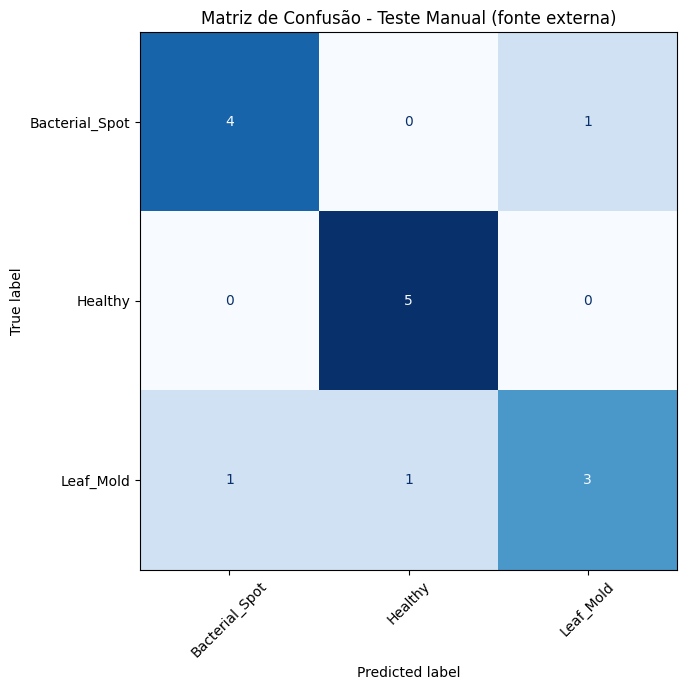

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

class_names = [idx_to_class[i] for i in range(len(idx_to_class))]

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão - Teste Manual (fonte externa)")
plt.tight_layout()
plt.show()

In [24]:
# Relatório por classe: precision, recall, f1-score e suporte (n de amostras) por classe.
# 'support' importa muito aqui: com poucas amostras por classe, olhe o número junto da métrica,
# não só a porcentagem isolada.
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

                precision    recall  f1-score   support

Bacterial_Spot      0.800     0.800     0.800         5
       Healthy      0.833     1.000     0.909         5
     Leaf_Mold      0.750     0.600     0.667         5

      accuracy                          0.800        15
     macro avg      0.794     0.800     0.792        15
  weighted avg      0.794     0.800     0.792        15



## Test-Time Augmentation (TTA)
Roda cada imagem de avaliação em algumas variações (original, flip horizontal, etc.), tira a média dos logits/probabilidades e só então decide a classe. Não muda o modelo nem o treino — só estabiliza a predição na hora da inferência. Útil especialmente quando o erro está em casos de borda entre classes parecidas (o caso de vocês agora).

In [25]:
import torch.nn.functional as F

def predict_tta(model, images):
    """Roda o modelo na imagem original + flip horizontal, faz a média das
    probabilidades (softmax) das duas passagens. images já deve estar
    normalizado (mesmo transform_eval) e no DEVICE."""
    model.eval()
    with torch.no_grad():
        logits_orig = model(images)
        logits_flip = model(torch.flip(images, dims=[3]))  # flip horizontal

        probs = (F.softmax(logits_orig, dim=1) + F.softmax(logits_flip, dim=1)) / 2
    return probs


# Reavaliando o eval_loader externo com TTA, para comparar com o resultado sem TTA
y_true_tta, y_pred_tta = [], []

for images, labels in eval_loader:
    images, labels = images.to(DEVICE), labels.to(DEVICE)
    probs = predict_tta(NET, images)
    preds = probs.argmax(dim=1)

    y_true_tta.extend(labels.cpu().numpy())
    y_pred_tta.extend(preds.cpu().numpy())

acc_tta = accuracy_score(y_true_tta, y_pred_tta)
print(f"Accuracy com TTA: {acc_tta * 100:.5f}%  (sem TTA: {acc * 100:.5f}%)")

Accuracy com TTA: 73.33333%  (sem TTA: 80.00000%)


# Salvando Modelo

In [26]:
# Arrumar mecanismo de save
import datetime as dt

class Save:
    def __init__(self):
        pass

    def __call__(self, t=dt.datetime.now()):
        self.time = "{}-{}-{} {}:{}:{}".format(t.day, t.month, t.year, t.hour, t.minute, t.second)
        self.classes = dataset.classes
        self.model_path = "./Models/Saved/Expert/Tomato/Tomato_1.pth" # os.getenv("MODEL_PATH")

        if os.path.isfile(self.model_path):
            os.remove(self.model_path)

        torch.save({
            "model_state_dict": NET.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names": self.classes,
            "num_classes": len(self.classes),
            "model_info": {
                "version": "1.0",
                "training_date": self.time,
                "accuracy": acc
            }
            }, self.model_path)

Save().__call__()